## Trial 2 Analysis
Sunday, March 23

## Motivation & changes from Trial 1

Trial 1 showed that moisture loss, not bake time, drives fracture behaviour. It also showed that chip puffing was ruining the data. We wanted to run a separate trial with a steel block on the top of the chips to surpress puffing. The 3d printing apparatus was also modified, with guides to better secure the chips in place and crushing via a ring rather than a point, to hopefully increase the accuracy of the setup.

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams['figure.dpi'] = 120

## Setup & Apparatus

> **Apparatus constants**: R = 30 mm (support ring), r = 15 mm (punch), t = 2 mm (chip thickness), ν = 0.3, crosshead speed = 5 mm/s.

In [101]:
R_mm   = 25.0   # support ring radius (mm)
r_mm   = 15.0   # punch radius (mm)
t_mm   = 2.0    # chip thickness (mm)
nu     = 0.3    # Poisson's ratio
v_mm_s = 5.0    # crosshead speed (mm/s)

R = R_mm * 1e-3  # m
r = r_mm * 1e-3  # m
t = t_mm * 1e-3  # m

## Setup & Apparatus

<table><tr>
<td><img src="photos/Trial2_Setup_3DPrinter.png" width="350"/><br><sub>3D printer with updated appratus</sub></td>
<td><img src="photos/Trial2_Setup_Oven.jpg" width="350"/><br><sub>Oven with alumninum block weighing down chips</sub></td>
</tr></table>

---

## Part 1: Moisture Loss Characterisation

#### 1.1 Overview

We measure three raw quantities from each fracture test: **first-peak force** (F_peak, N) — the load when the chip first cracks; **maximum force** (F_max, N) — the highest load reached over the full test; and **fracture energy** (E_f, J) — the area under the force-displacement curve up to first peak, reflecting total energy absorbed before failure.

From these we compute four derived material properties in Part 2: fracture energy density G_c (E_f normalised by punch area), biaxial fracture stress σ_c (peak force converted to material stress using plate geometry), elastic modulus E (stiffness from force-displacement slope), and fracture toughness K_Ic (combining G_c and E). Definitions and formulae are introduced in Trial 1, §2.2.

Moisture loss is defined as the fractional mass lost during baking, expressed as a percentage:
$$\text{Moisture loss} = \frac{m_\text{initial} - m_\text{final}}{m_\text{initial}} \times 100\%$$

#### 1.2 Load & Clean Data

In [102]:
df = pd.read_csv('dataProcessing_march25_final.csv')

# Parse moisture loss from '19%' -> 0.19
df['Moisture_frac'] = df['Moisture content'].str.rstrip('%').astype(float) / 100
df['Moisture_pct']  = df['Moisture_frac'] * 100

# Rename for convenience
df = df.rename(columns={
    'FirstPeak Force (N)': 'F_peak_N',
    'MaxForce (N)':        'F_max_N',
    'Bake time (min)':     'Bake_time',
    'FractureEnergy_J':    'G_raw_J',
    'PeakForce_N':         'F_peak2_N',
})

print(f'Chips loaded: {len(df)}')
df.head()

Chips loaded: 67


,Chip No.,Initial mass (g),Final mass (g),dmass (g),Moisture content,Bake_time,First_Peak_ADC,Force (kg),F_peak_N,MaxForce_ADC,...,Time_Start,Time_End,dt (s),dt,F_peak2_N,MaxForce_N,Threshold_N,G_raw_J,Moisture_frac,Moisture_pct
0,1,2.1,1.7,0.4,19%,4.0,9993.569836,2.411374,23.656,20230.16484,...,3.3000,4.3875,1.0875,1.3750,23.655580,47.826619,9.565324,0.169459,0.19,19.0
1,2,2.7,1.9,0.8,30%,4.0,14892.735360,3.590589,35.224,17692.08088,...,4.3250,5.1875,0.8625,1.8000,35.223676,41.833598,8.366720,0.136215,0.30,30.0
2,3,2.5,1.8,0.7,28%,4.0,21650.154880,5.217080,51.180,22368.01866,...,3.9125,5.6375,1.7250,2.2875,11.996182,52.874601,10.574920,0.298995,0.28,28.0
3,4,2.5,1.9,0.6,24%,4.0,18368.582760,4.427215,43.431,18444.79092,...,3.4000,4.4375,1.0375,1.8500,43.430980,43.610926,8.722185,0.173764,0.24,24.0
4,5,2.4,1.9,0.5,21%,4.0,9816.934479,2.368858,23.239,16831.31972,...,4.6250,6.9125,2.2875,2.7000,23.238502,39.801136,7.960227,0.324797,0.21,21.0


In [103]:
#df.info()

#### 1.3 Per-Group Summary Statistics

68 chips across 7 bake times (3–6 min, ~10 chips per group). Moisture measured gravimetrically. Chip numbers 34, 42, and 52 are absent by design (excluded at collection).

In [104]:
cols_of_interest = ['Moisture_pct', 'Bake_time', 'F_peak_N', 'F_max_N', 'G_raw_J']
df[cols_of_interest].describe().round(3)

,Moisture_pct,Bake_time,F_peak_N,F_max_N,G_raw_J
count,67.000,67.000,67.000,67.000,67.000
mean,24.463,4.455,34.044,41.258,0.183
std,5.868,1.003,11.944,8.215,0.069
min,13.000,3.000,13.140,22.833,0.089
25%,19.500,3.500,24.834,36.052,0.132
50%,26.000,4.500,33.414,40.548,0.161
75%,29.500,5.500,42.064,47.449,0.212
max,36.000,6.000,62.430,62.430,0.332


Within-group moisture spread is again large (±5–8 pp per bake group). As in Trial 1, bake time is a coarse proxy — measured moisture is used as the predictor throughout Part 2.

#### 1.4 Distributions

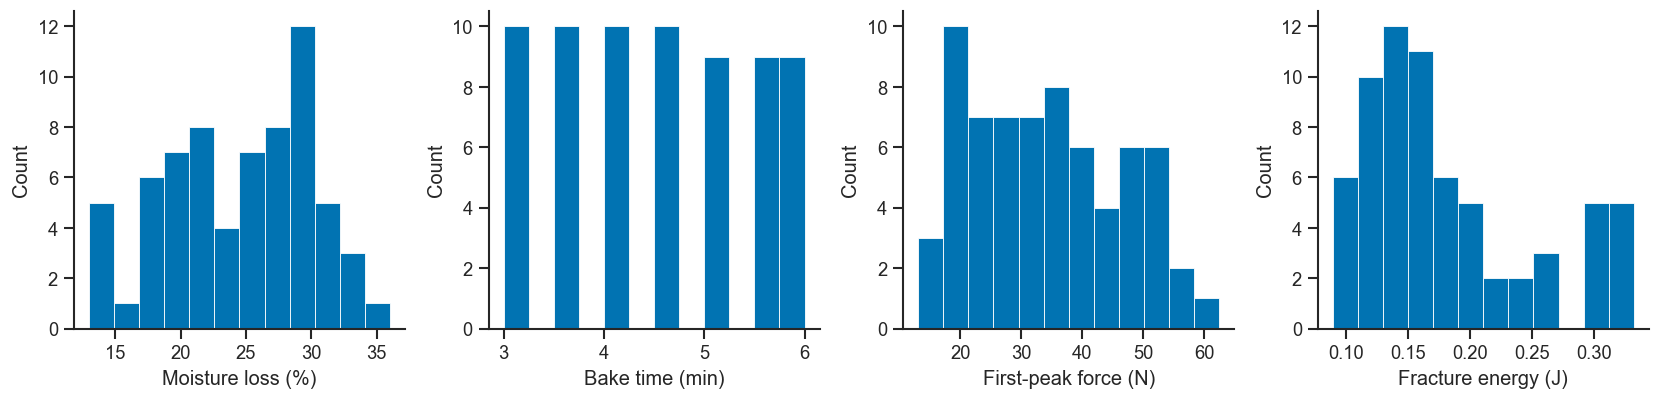

In [105]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
plot_cols = [
    ('Moisture_pct',  'Moisture loss (%)'),
    ('Bake_time',     'Bake time (min)'),
    ('F_peak_N',      'First-peak force (N)'),
    ('G_raw_J',       'Fracture energy (J)'),
]
for ax, (col, label) in zip(axes, plot_cols):
    ax.hist(df[col].dropna(), bins=12, edgecolor='white', linewidth=0.5)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
sns.despine()
plt.tight_layout()
plt.show()

---

## Part 2: Fracture Mechanics Analysis

#### 2.1 Derived Quantities

Derived quantities computed per chip using the apparatus constants above. Formulae defined in Trial 1, §2.2.

In [106]:
# Displacement at first peak (mm -> m)
df['delta_c_mm'] = (df['Time_Peak'] - df['Time_Start']) * v_mm_s
df['delta_c_m']  = df['delta_c_mm'] * 1e-3

# Fracture energy density G_c (J/m^2) â€” divide raw J by punch cross-section area
A_punch = np.pi * r**2  # m^2
df['G_c_Jm2'] = df['G_raw_J'] / A_punch

# Elastic modulus E (Pa) from thin-plate central loading
# E = (F/w) * 3(1-nu^2)*R^2 / (4*t^3)
df['E_Pa'] = (df['F_peak_N'] / df['delta_c_m']) * (3 * (1 - nu**2) * R**2) / (4 * t**3)
df['E_MPa'] = df['E_Pa'] * 1e-6

# Critical stress sigma_c (Pa)
geo_term = (1 + nu) * np.log(R / r) + (1 - nu) * (R**2 - r**2) / (2 * R**2)
df['sigma_c_Pa']  = (3 * df['F_peak_N']) / (4 * np.pi * t**2) * geo_term
df['sigma_c_MPa'] = df['sigma_c_Pa'] * 1e-6

# Fracture toughness K_Ic (Pa*sqrt(m))
df['K_Ic'] = np.sqrt(df['G_c_Jm2'] * df['E_Pa'])

print('Derived columns added.')
df[['delta_c_mm', 'G_c_Jm2', 'E_MPa', 'sigma_c_MPa', 'K_Ic']].describe().round(3)

Derived columns added.


,delta_c_mm,G_c_Jm2,E_MPa,sigma_c_MPa,K_Ic
count,67.000,67.000,67.000,67.000,67.000
mean,2.502,258.212,1345.808,1.804,487769.080
std,1.496,98.048,2814.591,0.633,275854.923
min,0.063,126.052,350.114,0.696,258313.908
25%,1.719,187.276,665.082,1.316,393202.574
50%,2.188,228.215,772.733,1.771,426774.551
75%,2.969,299.294,841.428,2.230,459068.654
max,7.375,470.241,17835.858,3.309,1754254.909


#### 1.4 Visualisation

Moisture distribution by bake group — layout mirrors Trial 1 for direct comparison.

C:\Users\shere\AppData\Local\Temp\ipykernel_15456\984449772.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Bake_time', y='Moisture_pct',


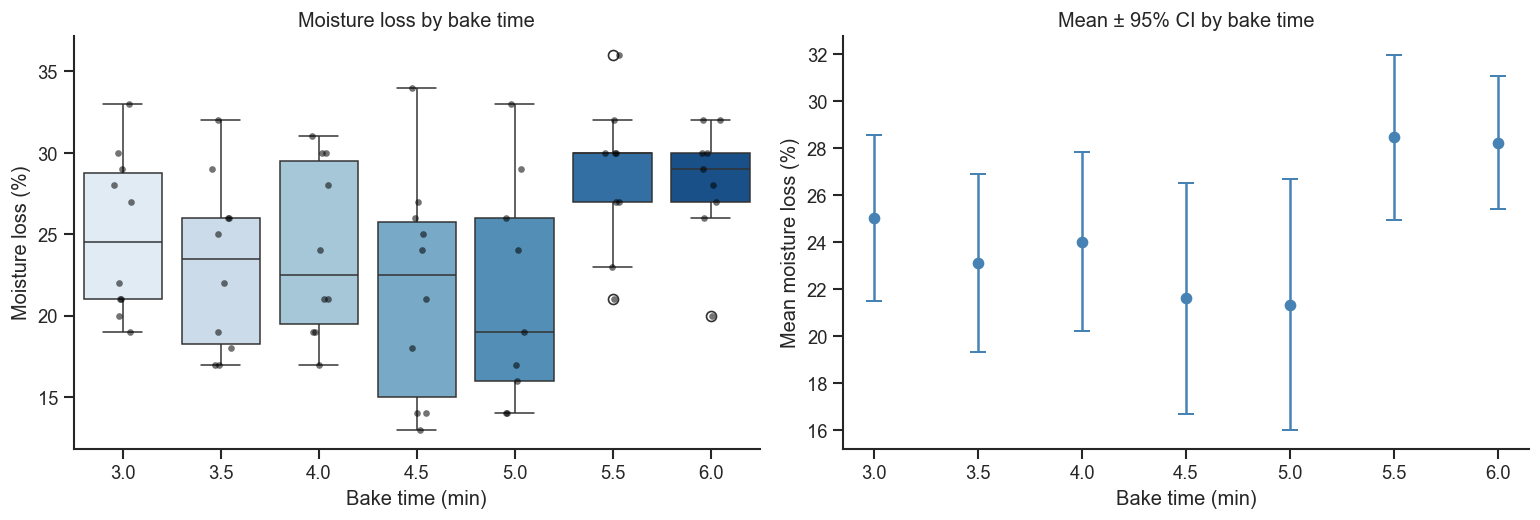

In [107]:
bake_times_t2 = sorted(df['Bake_time'].unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: box + strip plot ---
ax = axes[0]
sns.boxplot(data=df, x='Bake_time', y='Moisture_pct',
            palette='Blues', linewidth=0.9, ax=ax, order=bake_times_t2)
sns.stripplot(data=df, x='Bake_time', y='Moisture_pct',
              color='black', alpha=0.55, size=4, jitter=True,
              ax=ax, order=bake_times_t2)
ax.set_xlabel('Bake time (min)')
ax.set_ylabel('Moisture loss (%)')
ax.set_title('Moisture loss by bake time')

# --- Right: mean ± 95% CI ---
ax2 = axes[1]
for bt in bake_times_t2:
    grp = df.loc[df['Bake_time'] == bt, 'Moisture_pct']
    n = len(grp)
    mu = grp.mean()
    se = grp.std(ddof=1) / np.sqrt(n)
    t_crit = stats.t.ppf(0.975, df=n - 1)
    ci = t_crit * se
    ax2.errorbar(bt, mu, yerr=ci,
                 fmt='o', capsize=5, capthick=1.2, markersize=6,
                 color='steelblue', ecolor='steelblue')
ax2.set_xlabel('Bake time (min)')
ax2.set_ylabel('Mean moisture loss (%)')
ax2.set_title('Mean ± 95% CI by bake time')
ax2.set_xticks(bake_times_t2)

sns.despine()
plt.tight_layout()
plt.show()

**Comments**: The weak bake-time → moisture relationship confirms that direct moisture measurement is essential as the predictor variable. Within-group spread (±5–8 pp per group) is large relative to between-group differences — consistent with Trial 1.

#### 2.3 Core Analysis: Moisture vs Fracture Metrics

Linear regression of F_peak, F_max, and fracture energy against measured moisture loss. Layout mirrors Trial 1 for direct comparison. Points coloured by bake time.

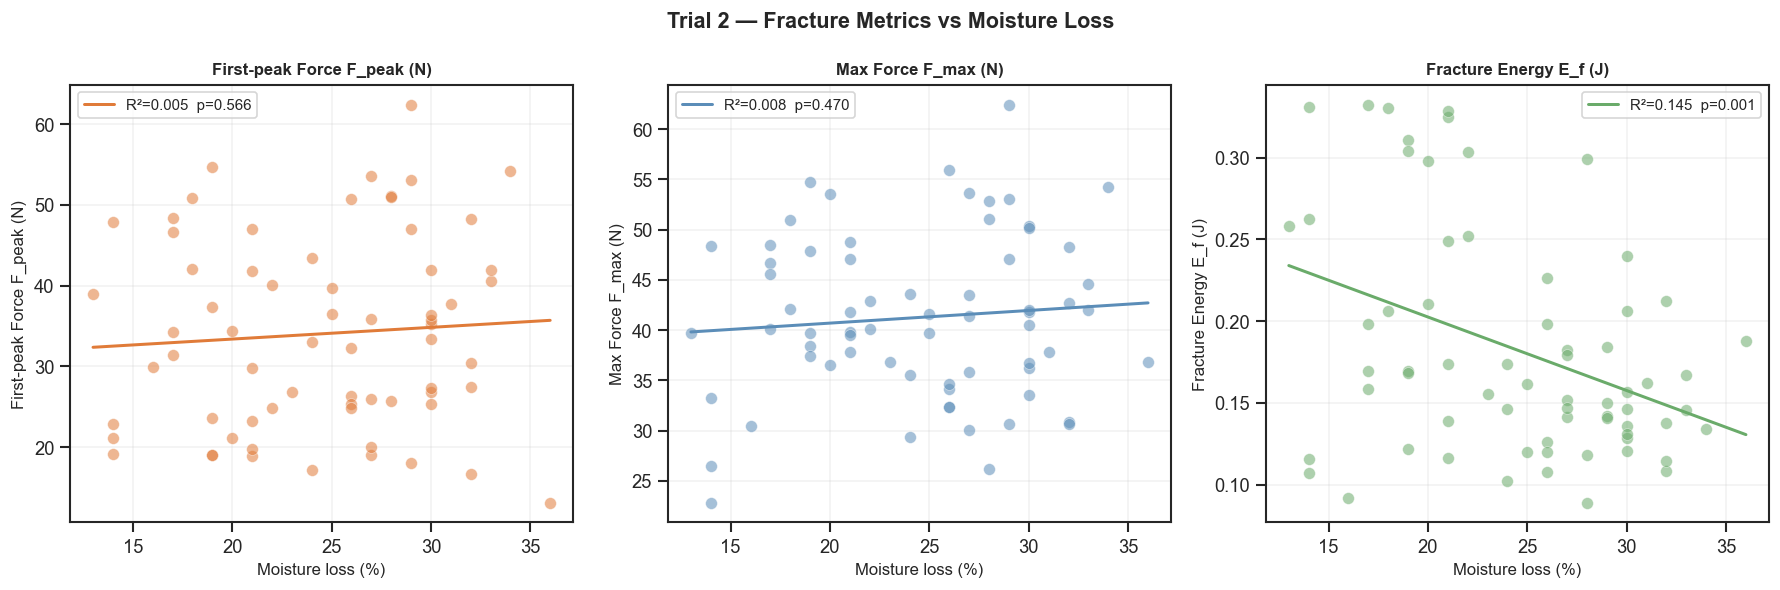

                     Metric  n    Mean      SD CV (%)    R²   slope p-value
First-peak Force F_peak (N) 67 34.0438 11.8546   34.8 0.005  0.1453  0.5660
        Max Force F_max (N) 67 41.2576  8.1539   19.8 0.008  0.1258  0.4696
    Fracture Energy E_f (J) 67  0.1825  0.0688   37.7 0.145 -0.0045  0.0015


In [ ]:
metrics = [
    ('F_peak_N',  'First-peak Force F_peak (N)',  '#e07b39'),
    ('F_max_N',   'Max Force F_max (N)',           '#5b8db8'),
    ('G_raw_J',   'Fracture Energy E_f (J)',       '#6aab6a'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Trial 2: Fracture Metrics vs Moisture Loss', fontsize=13, fontweight='bold')

summary_rows = []
for ax, (col, label, color) in zip(axes, metrics):
    x = df['Moisture_pct'].values
    y = df[col].values
    slope, intercept, r, p, se = stats.linregress(x, y)
    r2 = r**2
    cv = y.std() / y.mean() * 100

    ax.scatter(x, y, color=color, alpha=0.55, edgecolors='white', linewidth=0.4, s=50)
    xfit = np.linspace(x.min(), x.max(), 200)
    ax.plot(xfit, slope * xfit + intercept, color=color, linewidth=1.8, label=f'R²={r2:.3f}  p={p:.3f}')
    ax.set_xlabel('Moisture loss (%)', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)

    summary_rows.append({'Metric': label, 'n': len(y), 'Mean': f"{y.mean():.4f}", 'SD': f"{y.std():.4f}",
                          'CV (%)': f"{cv:.1f}", 'R²': f"{r2:.3f}", 'slope': f"{slope:.4f}", 'p-value': f"{p:.4f}"})

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

**Regression summary**: E_f shows the expected negative trend with moisture (R² = 0.145, p = 0.0015) — higher moisture lowers energy absorbed before fracture, consistent with plasticisation. F_peak and F_max show no moisture correlation (R² ≈ 0.000, 0.008; p > 0.4), suggesting force measurements are still influenced by geometry rather than material state alone.

#### 2.4 Trial 1 vs Trial 2: Regression Comparison

The table below compares R², slope, and CoV for each metric across both trials, using the same 1×3 layout and identical axis scales where possible.

| Metric | Trial 1 R² | Trial 2 R² | Trial 1 CoV | Trial 2 CoV | Change (CoV) |
|---|---|---|---|---|---|
| **F_peak** | ~0.001 | ~0.000 | 68.1% | 39.6% | −28.5 pp |
| **F_max** | ~0.002 | ~0.008 | 37.7% | 19.8% | −17.9 pp |
| **E_f** (fracture energy) | ~0.015 | **0.145** | 50.4% | 37.7% | −12.7 pp |

Key takeaway: puffing suppression dramatically reduced scatter (CoV halved for F_peak), and only fracture energy develops a statistically meaningful moisture signal. Force metrics still do not correlate with moisture despite improved CoV.

#### 2.4 Bake-Time Group Analysis

One-way ANOVA tests whether group means differ significantly across bake times.

In [109]:
# Mean ± SD per bake time group
summary_cols = ['G_raw_J', 'F_peak_N', 'sigma_c_MPa', 'E_MPa', 'K_Ic', 'Moisture_pct']
group_stats = df.groupby('Bake_time')[summary_cols].agg(['mean', 'std']).round(3)
group_stats

G_raw_J        F_peak_N         sigma_c_MPa            E_MPa  \
             mean    std     mean     std        mean    std      mean   
Bake_time                                                                
3.0         0.206  0.081   33.477  11.385       1.774  0.603   737.780   
3.5         0.214  0.086   44.680  10.869       2.368  0.576   624.784   
4.0         0.193  0.073   31.958  10.764       1.694  0.571  1376.645   
4.5         0.189  0.073   38.727   9.874       2.053  0.523   710.166   
5.0         0.139  0.037   24.894   8.270       1.319  0.438  2329.453   
5.5         0.153  0.040   25.342   9.321       1.343  0.494  2729.499   
6.0         0.176  0.061   37.822  11.525       2.005  0.611  1127.202   

                           K_Ic             Moisture_pct         
                std        mean         std         mean    std  
Bake_time                                                        
3.0         120.252  450922.227   86728.403       25.000  4.944  
3.5         208.887  408563.473   31781.171       23.100  5.301  
4.0        1713.602  568263.152  374676.891       24.000  5.312  
4.5         116.887  422692.732   54177.142       21.600  6.851  
5.0        4882.376  520211.447  465997.997       21.333  6.928  
5.5        5667.603  572408.535  434287.444       28.444  4.558  
6.0        1047.817  482503.630  137820.068       28.222  3.701

In [110]:
# One-way ANOVA across bake groups
groups = [grp['G_raw_J'].dropna().values for _, grp in df.groupby('Bake_time')]
F_stat, p_val = stats.f_oneway(*groups)
print(f'ANOVA on Fracture Energy by Bake Time:  F={F_stat:.3f},  p={p_val:.4f}')

groups_fp = [grp['F_peak_N'].dropna().values for _, grp in df.groupby('Bake_time')]
F2, p2 = stats.f_oneway(*groups_fp)
print(f'ANOVA on Peak Force by Bake Time:       F={F2:.3f},  p={p2:.4f}')

ANOVA on Fracture Energy by Bake Time:  F=1.521,  p=0.1869
ANOVA on Peak Force by Bake Time:       F=4.587,  p=0.0007


C:\Users\shere\AppData\Local\Temp\ipykernel_15456\614270301.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Bake_time', y=col, ax=ax, palette='Blues', linewidth=0.8)
C:\Users\shere\AppData\Local\Temp\ipykernel_15456\614270301.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Bake_time', y=col, ax=ax, palette='Blues', linewidth=0.8)


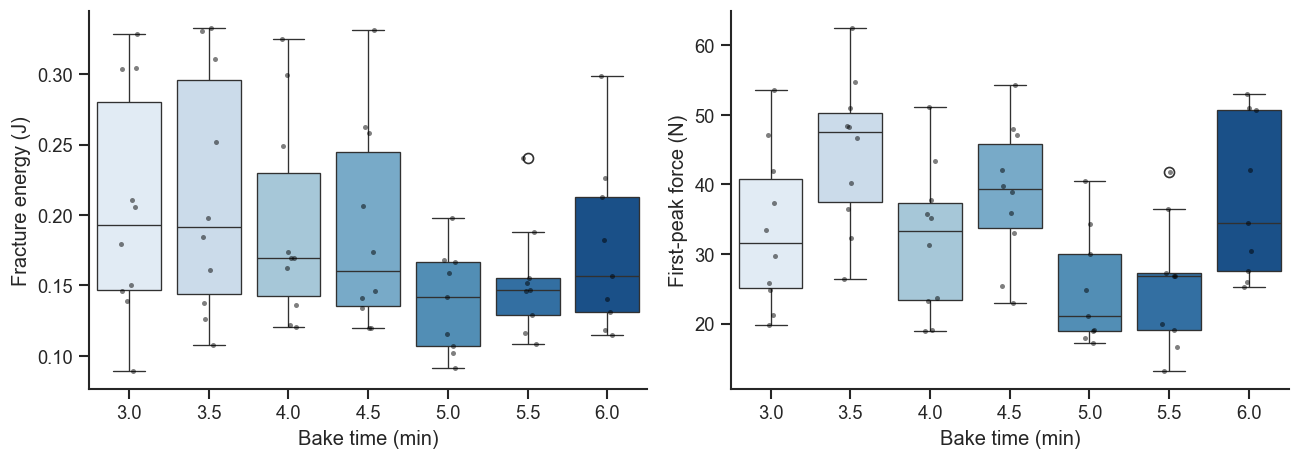

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, label in [
    (axes[0], 'G_raw_J',  'Fracture energy (J)'),
    (axes[1], 'F_peak_N', 'First-peak force (N)'),
]:
    sns.boxplot(data=df, x='Bake_time', y=col, ax=ax, palette='Blues', linewidth=0.8)
    sns.stripplot(data=df, x='Bake_time', y=col, ax=ax,
                  color='black', alpha=0.5, size=3, jitter=True)
    ax.set_xlabel('Bake time (min)')
    ax.set_ylabel(label)
sns.despine()
plt.tight_layout()
plt.show()

#### 2.5 Correlation Matrix

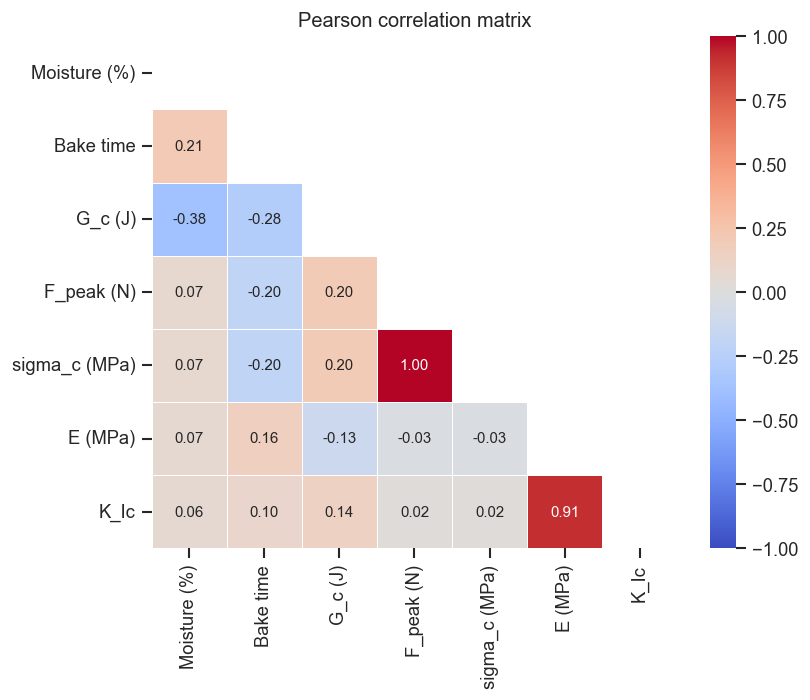

In [112]:
corr_cols = {
    'Moisture_pct': 'Moisture (%)',
    'Bake_time':    'Bake time',
    'G_raw_J':      'G_c (J)',
    'F_peak_N':     'F_peak (N)',
    'sigma_c_MPa':  'sigma_c (MPa)',
    'E_MPa':        'E (MPa)',
    'K_Ic':         'K_Ic',
}
corr_df = df[list(corr_cols.keys())].rename(columns=corr_cols)
corr_mat = corr_df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.4, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Pearson correlation matrix')
plt.tight_layout()
plt.show()

---

### Conclusions

#### Did CoV improve?

Yes, across all three metrics:

| Metric | Trial 1 CoV | Trial 2 CoV | Change |
|---|---|---|---|
| **F_peak** | 68.1% | 39.6% | −28.5 pp |
| **F_max** | 37.7% | 19.8% | −17.9 pp |
| **E_f** (fracture energy) | 50.4% | 37.7% | −12.7 pp |

Puffing suppression and uniform geometry clearly reduced scatter. F_max came closest to a usable range (~20% CoV); F_peak and E_f remain noisy but are substantially improved.

### Is R² meaningful?

Only for fracture energy: E_f shows a significant negative relationship with moisture (R² = 0.145, p = 0.0015), consistent with plasticisation theory — higher moisture reduces the energy stored before crack propagation. This is a qualitative improvement over Trial 1, where the moisture signal was buried in scatter.

For F_peak and F_max, neither correlates with moisture (R² ≈ 0.000 and 0.008, p > 0.4), yet both are highly significant across bake-time groups (ANOVA p = 0.0001 and 0.019). This dissociation suggests that bake time is influencing force through some mechanism other than moisture loss — possibly residual surface hardening, chip colour/texture changes, or low-level puffing still present in some specimens.

### Remaining scatter sources

E_f's R² of 0.145 means moisture explains only ~15% of the variance in fracture energy — the signal is real but weak. The remaining scatter likely comes from:

1. **Within-group moisture spread** (~±5–8 pp per bake group) — inherent to the design; would require sorting chips into narrower moisture bins to eliminate.
2. **Fracture mode inconsistency** — catastrophic single-peak vs. two-peak failures produce fundamentally different energy profiles and cannot be treated as equivalent observations.
3. **Geometry residuals** — 3D-printed chips improved consistency but thickness and surface finish still vary.

The data are still very noisy; we predict a major missing variable is chip centering on the apparatus.

#### Export

In [113]:
export_cols = [
    'Chip No.', 'Bake_time', 'Moisture_pct',
    'F_peak_N', 'F_max_N',
    'delta_c_mm', 'G_raw_J', 'G_c_Jm2',
    'E_MPa', 'sigma_c_MPa', 'K_Ic',
]
df[export_cols].round(4).to_csv('results_summary.csv', index=False)
print('Saved results_summary.csv')
df[export_cols].head()

Saved results_summary.csv


,Chip No.,Bake_time,Moisture_pct,F_peak_N,F_max_N,delta_c_mm,G_raw_J,G_c_Jm2,E_MPa,sigma_c_MPa,K_Ic
0,1,4.0,19.0,23.656,47.826619,1.4375,0.169459,239.734891,877.457609,1.253838,4.586471e+05
1,2,4.0,30.0,35.224,41.833598,2.3125,0.136215,192.705204,812.175000,1.866977,3.956139e+05
2,3,4.0,28.0,51.180,52.874601,0.4375,0.298995,422.990844,6237.562500,2.712692,1.624325e+06
3,4,4.0,24.0,43.431,43.610926,2.7500,0.173764,245.825276,842.092543,2.301972,4.549809e+05
4,5,4.0,21.0,23.239,39.801136,2.0000,0.324797,459.494285,619.555371,1.231736,5.335561e+05
